# Step 1: Import Libraries

In [25]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.preprocessing import StandardScaler
from xgboost import XGBRegressor
import joblib
import warnings
warnings.filterwarnings('ignore')


In [26]:
# CSV file load karna

df = pd.read_csv('house_price_prediction.csv')

# Data ki pehli 5 rows dekhna
print("Dataset Overview:")
print(df.head())
print("\nDataset Shape:", df.shape)
print("\nColumn Names:", df.columns.tolist())

Dataset Overview:
   Area_SqFt  Bedrooms  Bathrooms  Location_Rating  House_Age_Years  \
0       1763         3          1                4               12   
1       2447         4          3                5               23   
2       2261         4          2                3               20   
3       2499         3          3                2                5   
4       1499         3          2                4               21   

   Has_Garden  Price_USD  
0           1     522000  
1           1     698000  
2           1     593000  
3           0     631000  
4           0     459000  

Dataset Shape: (120, 7)

Column Names: ['Area_SqFt', 'Bedrooms', 'Bathrooms', 'Location_Rating', 'House_Age_Years', 'Has_Garden', 'Price_USD']


In [27]:
df

,Area_SqFt,Bedrooms,Bathrooms,Location_Rating,House_Age_Years,Has_Garden,Price_USD
0,1763,3,1,4,12,1,522000
1,2447,4,3,5,23,1,698000
2,2261,4,2,3,20,1,593000
3,2499,3,3,2,5,0,631000
4,1499,3,2,4,21,0,459000
...,...,...,...,...,...,...,...
115,1351,3,2,4,14,0,487000
116,2774,4,3,3,19,1,668000
117,3901,4,4,4,20,1,933000
118,2385,4,3,5,23,1,675000


# Step 2: Exploratory Data Analysis (EDA)

In [28]:
# Data information
print("\nDataset Information:")
print(df.info())


Dataset Information:
<class 'pandas.DataFrame'>
RangeIndex: 120 entries, 0 to 119
Data columns (total 7 columns):
 #   Column           Non-Null Count  Dtype
---  ------           --------------  -----
 0   Area_SqFt        120 non-null    int64
 1   Bedrooms         120 non-null    int64
 2   Bathrooms        120 non-null    int64
 3   Location_Rating  120 non-null    int64
 4   House_Age_Years  120 non-null    int64
 5   Has_Garden       120 non-null    int64
 6   Price_USD        120 non-null    int64
dtypes: int64(7)
memory usage: 6.7 KB
None


In [29]:
# Statistical summary
print("\nStatistical Summary:")
print(df.describe())


Statistical Summary:
         Area_SqFt    Bedrooms  Bathrooms  Location_Rating  House_Age_Years  \
count   120.000000  120.000000  120.00000       120.000000       120.000000   
mean   2543.991667    3.508333    2.52500         3.125000        12.258333   
std     873.321059    1.069012    0.95233         1.405646         7.152006   
min     903.000000    1.000000    1.00000         1.000000         0.000000   
25%    1844.250000    3.000000    2.00000         2.000000         7.000000   
50%    2496.500000    3.000000    3.00000         3.000000        13.000000   
75%    3212.750000    4.000000    3.00000         4.000000        18.000000   
max    4179.000000    6.000000    5.00000         5.000000        24.000000   

       Has_Garden     Price_USD  
count  120.000000  1.200000e+02  
mean     0.616667  6.539583e+05  
std      0.488237  1.802673e+05  
min      0.000000  2.450000e+05  
25%      0.000000  5.102500e+05  
50%      1.000000  6.515000e+05  
75%      1.000000  8.042500e

In [30]:
# Missing values check
print("\nMissing Values:")
print(df.isnull().sum())


Missing Values:
Area_SqFt          0
Bedrooms           0
Bathrooms          0
Location_Rating    0
House_Age_Years    0
Has_Garden         0
Price_USD          0
dtype: int64


In [31]:
# Data types check
print("\nData Types:")
print(df.dtypes)


Data Types:
Area_SqFt          int64
Bedrooms           int64
Bathrooms          int64
Location_Rating    int64
House_Age_Years    int64
Has_Garden         int64
Price_USD          int64
dtype: object


# Step 3: Feature Selection


In [32]:
X = df[['Area_SqFt', 'Bedrooms', 'Bathrooms']]
y = df['Price_USD']

print("\nSelected Features for Model:")
print("Independent Variables (X): Area_SqFt, Bedrooms, Bathrooms")
print("Dependent Variable (y): Price_USD")
print("\nFeatures Shape:", X.shape)
print("Target Shape:", y.shape)


Selected Features for Model:
Independent Variables (X): Area_SqFt, Bedrooms, Bathrooms
Dependent Variable (y): Price_USD

Features Shape: (120, 3)
Target Shape: (120,)


# Step 4: Data Visualization

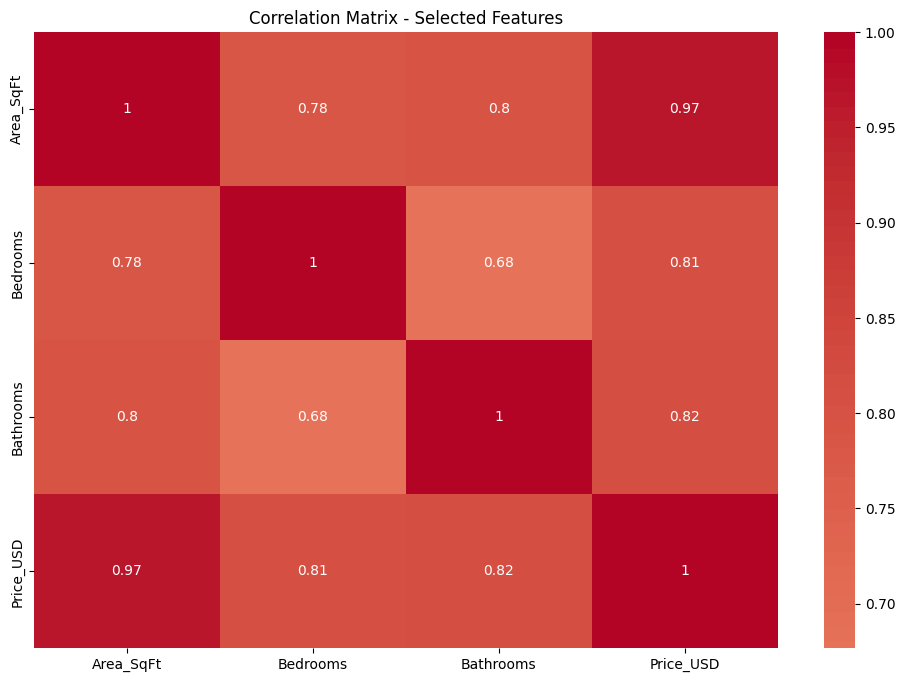

In [33]:
# Correlation matrix
plt.figure(figsize=(12, 8))
correlation_matrix = df[['Area_SqFt', 'Bedrooms', 'Bathrooms', 'Price_USD']].corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0)
plt.title('Correlation Matrix - Selected Features')
plt.show()

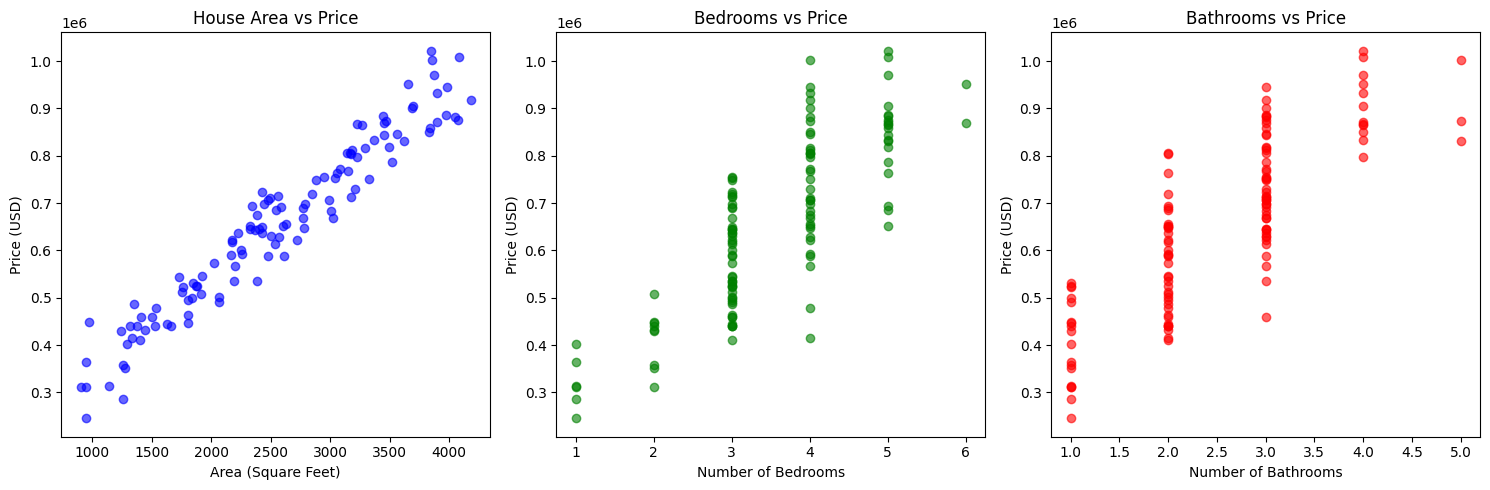

In [34]:
# Scatter plots for each feature vs Price
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Area vs Price
axes[0].scatter(X['Area_SqFt'], y, alpha=0.6, color='blue')
axes[0].set_xlabel('Area (Square Feet)')
axes[0].set_ylabel('Price (USD)')
axes[0].set_title('House Area vs Price')

# Bedrooms vs Price
axes[1].scatter(X['Bedrooms'], y, alpha=0.6, color='green')
axes[1].set_xlabel('Number of Bedrooms')
axes[1].set_ylabel('Price (USD)')
axes[1].set_title('Bedrooms vs Price')

# Bathrooms vs Price
axes[2].scatter(X['Bathrooms'], y, alpha=0.6, color='red')
axes[2].set_xlabel('Number of Bathrooms')
axes[2].set_ylabel('Price (USD)')
axes[2].set_title('Bathrooms vs Price')

plt.tight_layout()
plt.show()

# Step 5: Data Splitting

In [35]:
# Train-Test split (80-20)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("\nData Split Results:")
print(f"Training Set Size: {X_train.shape[0]} samples")
print(f"Testing Set Size: {X_test.shape[0]} samples")
print(f"Training Features Shape: {X_train.shape}")
print(f"Testing Features Shape: {X_test.shape}")


Data Split Results:
Training Set Size: 96 samples
Testing Set Size: 24 samples
Training Features Shape: (96, 3)
Testing Features Shape: (24, 3)


# Step 6: Model Training (Linear Regression)

In [36]:
# Initialize the Linear Regression Model
model = LinearRegression()

# Train the model using the training data
print("\nTraining the Linear Regression Model...")
model.fit(X_train, y_train)
print("Model training completed successfully.")

# Print the Model Coefficients and Intercept
print(f"\nModel Intercept: {model.intercept_:.2f}")
print("Model Coefficients:")
for col, coef in zip(X.columns, model.coef_):
    print(f" - {col}: {coef:.2f}")


Training the Linear Regression Model...
Model training completed successfully.

Model Intercept: 112390.47
Model Coefficients:
 - Area_SqFt: 154.71
 - Bedrooms: 22132.21
 - Bathrooms: 28606.31


# Step 7: Model Evaluation & Predictions

In [37]:
# Make predictions on the testing dataset
y_pred = model.predict(X_test)

# Calculate Evaluation Metrics
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("\nModel Evaluation Metrics (Testing Performance):")
print(f"Mean Absolute Error (MAE): ${mae:,.2f}")
print(f"Mean Squared Error (MSE): {mse:,.2f}")
print(f"Root Mean Squared Error (RMSE): ${rmse:,.2f}")
print(f"R-squared Score (R²): {r2:.4f} (or {r2*100:.2f}%)")


Model Evaluation Metrics (Testing Performance):
Mean Absolute Error (MAE): $36,812.02
Mean Squared Error (MSE): 1,925,067,851.82
Root Mean Squared Error (RMSE): $43,875.60
R-squared Score (R²): 0.9394 (or 93.94%)


# Step 8: Visualization of Results

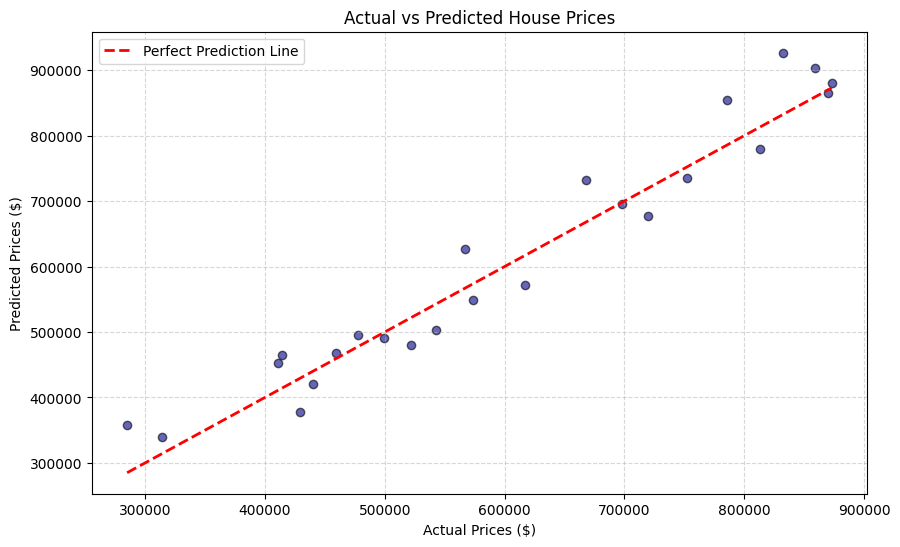

In [38]:
# Plotting Actual vs Predicted Prices
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred, alpha=0.6, color='darkblue', edgecolors='k')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2, label='Perfect Prediction Line')
plt.xlabel('Actual Prices ($)')
plt.ylabel('Predicted Prices ($)')
plt.title('Actual vs Predicted House Prices')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

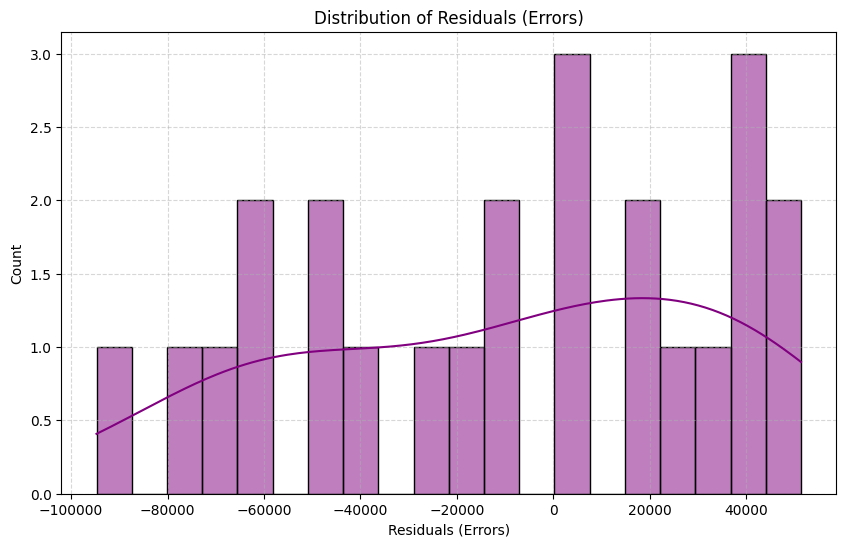

In [39]:
# Plotting Residuals Distribution (Errors)
residuals = y_test - y_pred
plt.figure(figsize=(10, 6))
sns.histplot(residuals, kde=True, color='purple', bins=20)
plt.xlabel('Residuals (Errors)')
plt.title('Distribution of Residuals (Errors)')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

# Step 9: Testing with a Sample Custom Prediction

In [40]:
# Creating a dummy house data to test model predictions
# Features format: [['Area_SqFt', 'Bedrooms', 'Bathrooms']]
sample_house = np.array([[2200, 3, 2]])

# Predict the price for the custom sample
predicted_price = model.predict(sample_house)

print("\nCustom House Price Prediction:")
print(f"Features -> Area: 2,200 SqFt, Bedrooms: 3, Bathrooms: 2")
print(f"Predicted Price: ${predicted_price[0]:,.2f}")


Custom House Price Prediction:
Features -> Area: 2,200 SqFt, Bedrooms: 3, Bathrooms: 2
Predicted Price: $576,353.81
